K-mer vs foundation model embeddings.
MCC comparison on 57 genomic classification datasets.
Claim: k-mer frequency vectors are as informative as (or better than) pretrained FM embeddings.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_context('paper', font_scale=1.1)

plt.rcParams.update({
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 15,
})

FIGURES_PDF_DIR = Path('../results/figures_pdf')
FIGURES_PDF_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    path = FIGURES_PDF_DIR / f'{filename}.pdf'
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved figure: {path}')

RECORDS      = '../results/classification/records.csv'
RECORDS_PCA  = '../results/classification/records_pca.csv'
RECORDS_CONCAT = '../results/concat/records_concat_best.csv'

RECORDS_DECOMP = '../results/classification/records_decomposition.csv'
RECORDS_BESTK  = '../results/classification/records_best_k_analysis.csv'
RECORDS_EFF   = '../results/exploratory/efficiency.csv'
RECORDS_REG   = '../results/regression/lra_records.csv'

# Readable names for FM models
FM_LABELS = {
    'fm_NTv3_650M_pre_MCC':                        'NTv3-650M',
    'fm_hyenadna-medium-160k-seqlen-hf_MCC':       'HyenaDNA-160k',
    'fm_DNABERT-2-117M_MCC':                       'DNABERT-2',
}

# ── utility functions ─────────────────────────────────────────────────────────

def load_records():
    df = pd.read_csv(RECORDS, index_col=0)
    df.index.name = 'dataset'
    df['group'] = df.index.str.split('/').str[0]
    df['short'] = df.index.str.split('/').str[1]
    return df


def kmer_mcc_cols(df, include_multi=True):
    cols = [c for c in df.columns if c.startswith('kmer_k') and c.endswith('_MCC')]
    if include_multi:
        cols += [c for c in df.columns if c.startswith('kmer_multi') and c.endswith('_MCC')]
    return cols


def fm_mcc_cols(df):
    """Exclude evo2 (all-zero results)."""
    return [c for c in df.columns
            if c.startswith('fm_') and c.endswith('_MCC') and 'evo2' not in c]


def best_kmer(df):
    cols = kmer_mcc_cols(df)
    return df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1).rename('best_kmer_MCC')


def best_fm(df):
    cols = fm_mcc_cols(df)
    return df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1).rename('best_fm_MCC')


def dataset_palette(df):
    groups = sorted(df['group'].dropna().unique())
    cmap = plt.colormaps['tab20']
    return {g: cmap(i) for i, g in enumerate(groups)}


# ── load data ─────────────────────────────────────────────────────────────────
df      = load_records()
df_pca  = pd.read_csv(RECORDS_PCA, index_col=0)
df_pca  = df_pca[~df_pca.index.duplicated(keep='last')]   # drop duplicate 'Promoter_B_amylolique'
df_pca['group'] = df_pca.index.str.split('/').str[0]

df_concat = pd.read_csv(RECORDS_CONCAT)
df_decomp = pd.read_csv(RECORDS_DECOMP, index_col=0)
df_bestk  = pd.read_csv(RECORDS_BESTK, index_col=0)
df_eff    = pd.read_csv(RECORDS_EFF)
df_reg    = pd.read_csv(RECORDS_REG)
df_concat = df_concat.set_index('dataset')

palette = dataset_palette(df)

print(f"Records:  {len(df)} datasets, {len(df.columns)} columns")
print(f"PCA:      {len(df_pca)} datasets")
print(f"Concat:   {len(df_concat)} datasets")

Records:  57 datasets, 63 columns
PCA:      58 datasets
Concat:   57 datasets


---
## 1. Per-dataset comparison: FM embeddings vs best k-mer
Each point is a dataset. Above the diagonal: FM wins; below: k-mer wins.  
One subplot per FM model (Evo2 excluded, MCC ≈ 0 across datasets).

Saved figure: ../results/figures_pdf/01_fm_vs_kmer_by_model.pdf


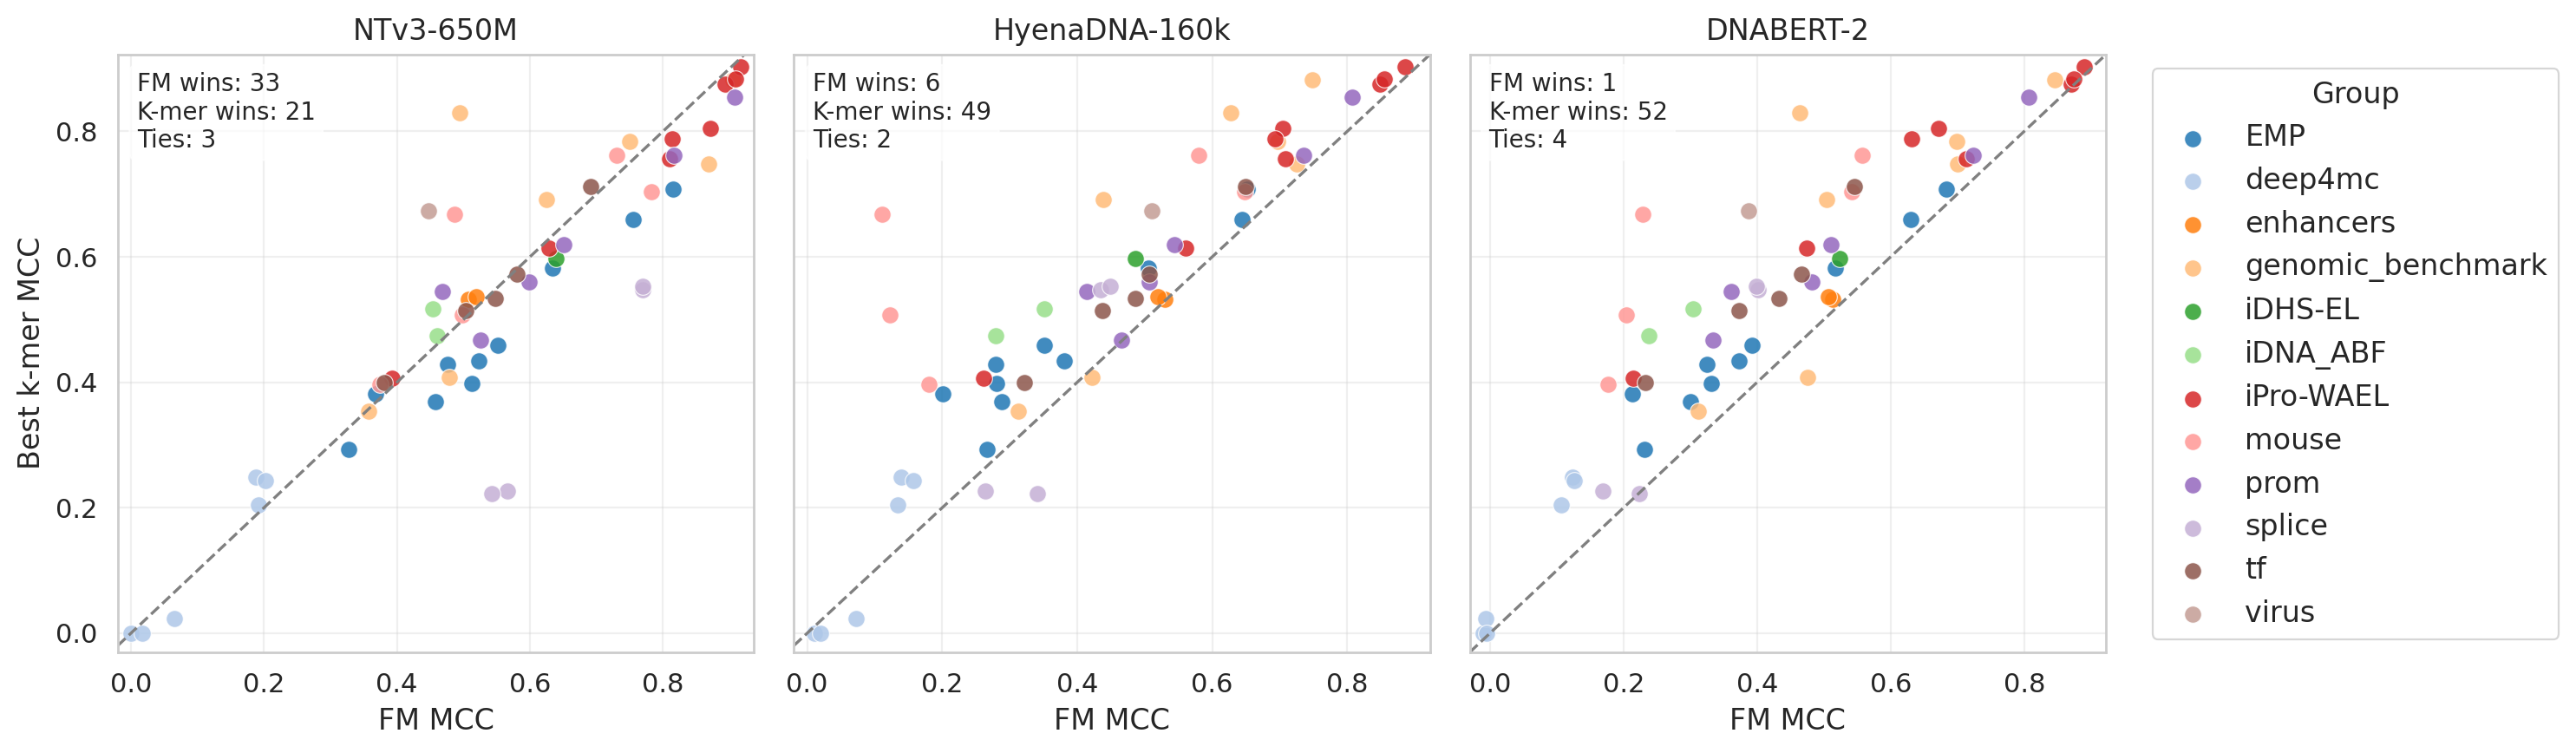

In [15]:
metric = 'MCC'
TIE_EPS = 0.01  # treat |FM - k-mer| <= eps as tie
best_k = best_kmer(df)
fm_cols = list(FM_LABELS.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, col in zip(axes, fm_cols):
    x = pd.to_numeric(df[col], errors='coerce')   # FM MCC
    y = best_k                                     # best k-mer MCC

    for g, sub in df.groupby('group'):
        ax.scatter(x.loc[sub.index], y.loc[sub.index],
                   label=g, alpha=0.85, s=50, color=palette[g],
                   edgecolors='white', lw=0.4)

    lo = np.nanmin([x.min(), y.min()]) - 0.02
    hi = np.nanmax([x.max(), y.max()]) + 0.02
    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1.2)

    valid = pd.concat([x, y], axis=1).dropna()
    diff = valid.iloc[:, 0] - valid.iloc[:, 1]
    fm_wins   = (diff > TIE_EPS).sum()
    kmer_wins = (diff < -TIE_EPS).sum()
    ties      = ((diff >= -TIE_EPS) & (diff <= TIE_EPS)).sum()
    ax.text(0.03, 0.97, f'FM wins: {fm_wins}\nK-mer wins: {kmer_wins}\nTies: {ties}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_title(FM_LABELS[col])
    ax.set_xlabel('FM MCC')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

axes[0].set_ylabel('Best k-mer MCC')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                title='Group', fontsize=12, title_fontsize=12)
plt.tight_layout()
save_figure(fig, '01_fm_vs_kmer_by_model')
plt.show()

**Notes — strongest margins (MCC):**
**K-mer ≫ NTv3 (top 3):**
- `genomic_benchmark/regulatory_region_type` (Δ = -0.336)
- `virus/covid_variants` (Δ = -0.225)
- `mouse/mouse_TFBS_4` (Δ = -0.181)




---
## 2. Summary by biological category
Compact table with per-category means/medians and a plot of the Δ MCC distribution (NTv3 − best k-mer).
Values rounded for readability; prioritize pattern clarity over detail.


,N,Seq len,GC,Best k,MCC k-mer,MCC NTv3,NTv3 wins,R²,Resid > k-mer,Synergy,Δ concat
biocat_label,,,,,,,,,,,
Enhancer/Generic,11,347,0.45,4,0.673,0.519,5,0.43,3,-0.012,-0.021
Histone (Yeast),10,500,0.38,6,0.431,0.518,9,0.49,3,0.062,-0.003
Methylation,8,41,0.49,4,0.224,0.190,2,0.57,3,0.002,-0.025
Promoter,14,450,0.53,4,0.759,0.812,12,0.44,4,0.009,-0.006
Splice,4,500,0.45,4,0.387,0.668,4,0.51,4,0.076,-0.003
TFBS,10,101,0.56,5,0.553,0.526,3,0.49,0,-0.005,-0.007


Saved figure: ../results/figures_pdf/02_category_delta_ntv3_kmer.pdf


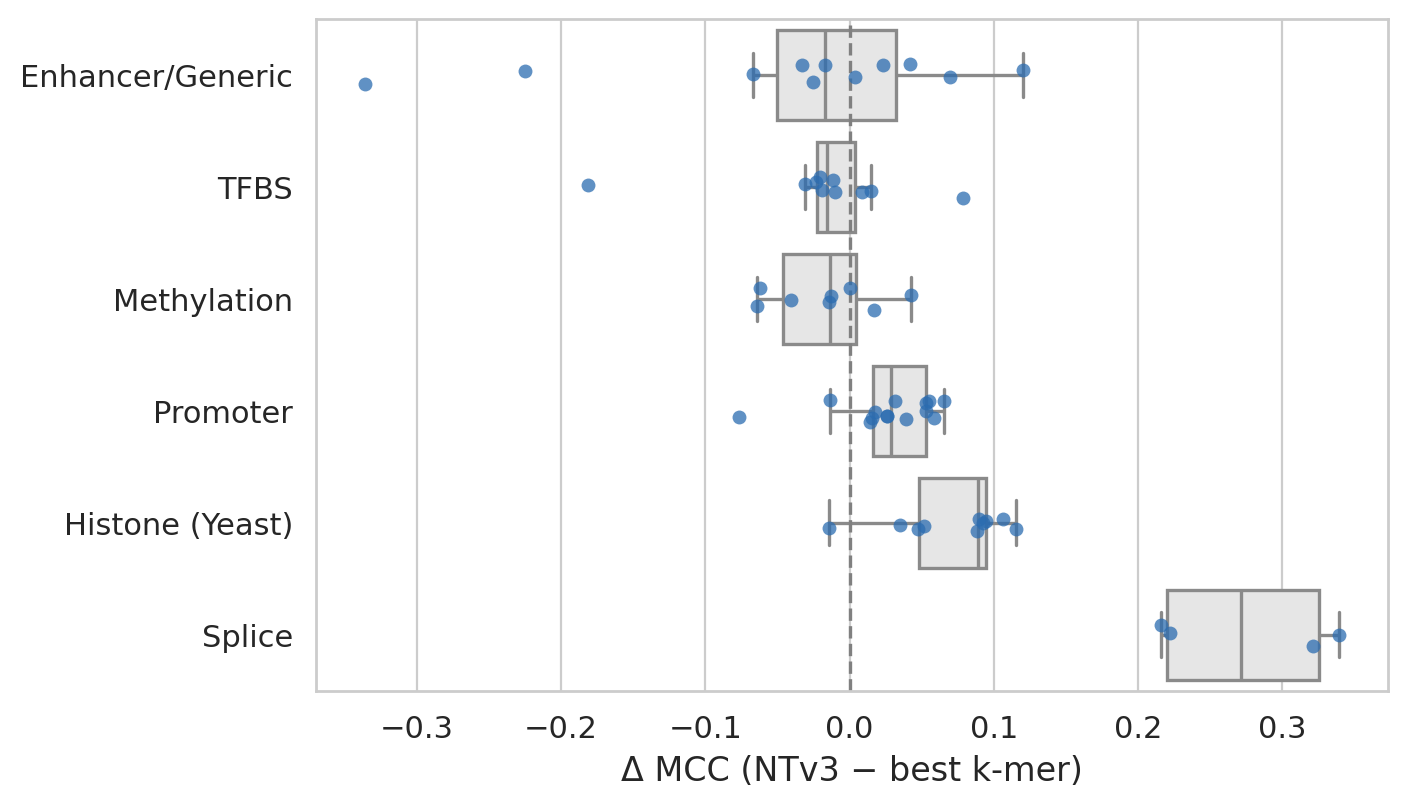

In [16]:
# ── Section 2: category summary ─────────────────────────────────────────
sns.set_style('whitegrid')

CAT_LABELS = {
    'histone': 'Histone (Yeast)',
    'methylation': 'Methylation',
    'promoter': 'Promoter',
    'splice': 'Splice',
    'TFBS': 'TFBS',
    'enhancer/generic': 'Enhancer/Generic',
}

def mode_or_nan(s):
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan

# dataset-level table
cat = df_bestk[['biocat', 'seq_len_mean', 'gc_content_mean', 'best_k']].copy()
cat['best_kmer_MCC'] = best_kmer(df)
cat['ntv3_MCC'] = pd.to_numeric(df['fm_NTv3_650M_pre_MCC'], errors='coerce')
cat['delta_ntv3_kmer'] = cat['ntv3_MCC'] - cat['best_kmer_MCC']

# decomposition (k=6)
cat['R2'] = pd.to_numeric(df_decomp['ridge_k6_NTv3_650M_pre_R2'], errors='coerce')
cat['proj_MCC'] = pd.to_numeric(df_decomp['proj_k6_NTv3_650M_pre_MCC'], errors='coerce')
cat['resid_MCC'] = pd.to_numeric(df_decomp['resid_k6_NTv3_650M_pre_MCC'], errors='coerce')
cat['synergy'] = cat['ntv3_MCC'] - np.maximum(cat['proj_MCC'], cat['resid_MCC'])
cat['resid_gt_kmer'] = (cat['resid_MCC'] > cat['best_kmer_MCC']).astype(int)

# concatenation: delta vs best single model
cat['concat_MCC'] = pd.to_numeric(df_concat['MCC'], errors='coerce')
cat['delta_concat'] = cat['concat_MCC'] - cat[['best_kmer_MCC', 'ntv3_MCC']].max(axis=1)

cat['biocat_label'] = cat['biocat'].map(CAT_LABELS)

summary = (cat
    .groupby('biocat_label')
    .agg(
        N=('best_kmer_MCC', 'count'),
        seq_len=('seq_len_mean', 'mean'),
        GC=('gc_content_mean', 'mean'),
        best_k=('best_k', mode_or_nan),
        MCC_kmer=('best_kmer_MCC', 'median'),
        MCC_NTv3=('ntv3_MCC', 'median'),
        NTv3_wins=('delta_ntv3_kmer', lambda s: (s > 0).sum()),
        R2=('R2', 'mean'),
        resid_gt_kmer=('resid_gt_kmer', 'sum'),
        synergy=('synergy', 'mean'),
        delta_concat=('delta_concat', 'mean'),
    )
)

summary_fmt = summary.copy()
summary_fmt['seq_len'] = summary_fmt['seq_len'].round(0).astype(int)
summary_fmt['GC'] = summary_fmt['GC'].round(2)
summary_fmt['best_k'] = summary_fmt['best_k'].astype('Int64')
summary_fmt['MCC_kmer'] = summary_fmt['MCC_kmer'].round(3)
summary_fmt['MCC_NTv3'] = summary_fmt['MCC_NTv3'].round(3)
summary_fmt['R2'] = summary_fmt['R2'].round(2)
summary_fmt['synergy'] = summary_fmt['synergy'].round(3)
summary_fmt['delta_concat'] = summary_fmt['delta_concat'].round(3)


summary_fmt = summary_fmt.rename(columns={
    'seq_len': 'Seq len',
    'GC': 'GC',
    'best_k': 'Best k',
    'MCC_kmer': 'MCC k-mer',
    'MCC_NTv3': 'MCC NTv3',
    'NTv3_wins': 'NTv3 wins',
    'R2': 'R²',
    'resid_gt_kmer': 'Resid > k-mer',
    'synergy': 'Synergy',
    'delta_concat': 'Δ concat',
})

display(summary_fmt)

# plot: Δ MCC by category
order = (cat.groupby('biocat_label')['delta_ntv3_kmer']
         .median()
         .sort_values()
         .index.tolist())

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.boxplot(data=cat, y='biocat_label', x='delta_ntv3_kmer', order=order,
            color='#E6E6E6', fliersize=0, linewidth=1.2, ax=ax)
sns.stripplot(data=cat, y='biocat_label', x='delta_ntv3_kmer', order=order,
              size=5, alpha=0.75, color='#2B6CB0', ax=ax)
ax.axvline(0, ls='--', c='gray', lw=1.2)
ax.set_xlabel('Δ MCC (NTv3 − best k-mer)')
ax.set_ylabel('')
plt.tight_layout()
save_figure(fig, '02_category_delta_ntv3_kmer')
plt.show()

---
## 3. Effect of sequence length
Scatter of Δ MCC (NTv3 − best k-mer) vs mean sequence length,
with summary by length bins.


Saved figure: ../results/figures_pdf/03_sequence_length_effect.pdf


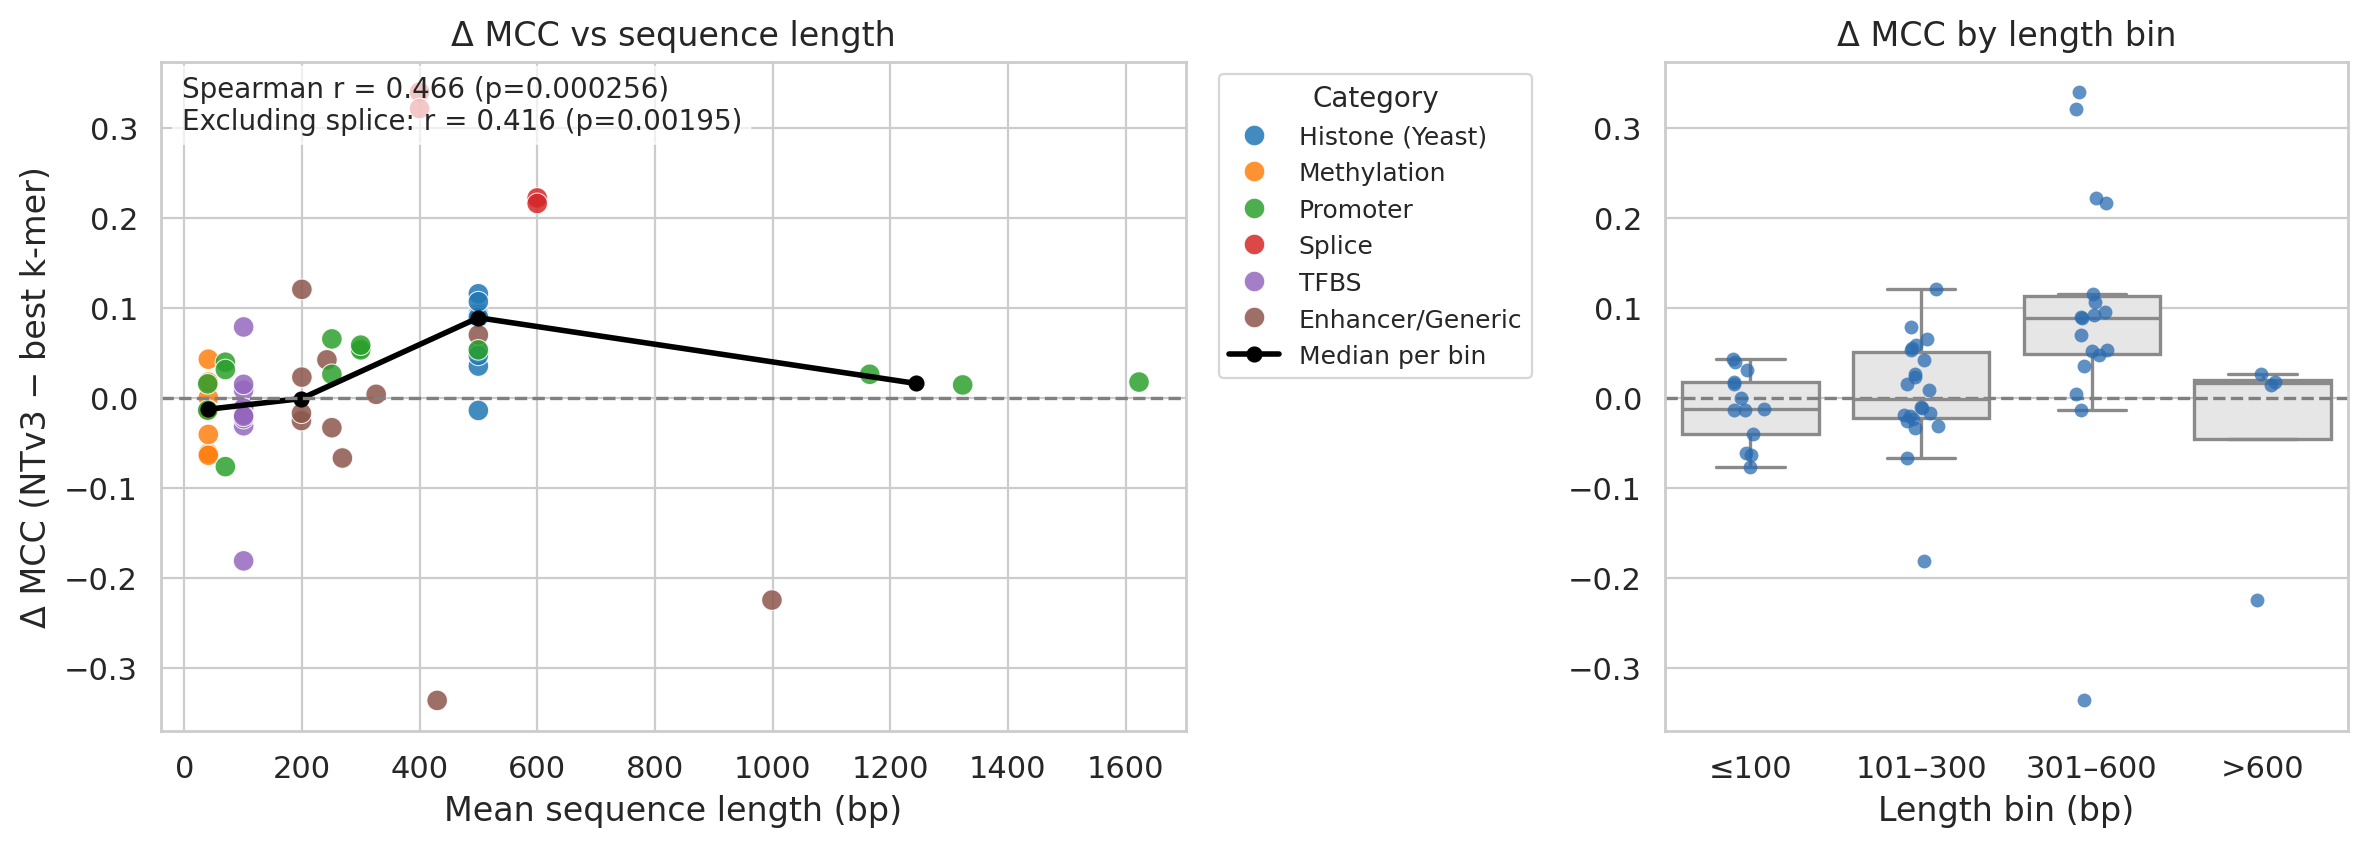

In [17]:
# ── Section 3: sequence length effect ────────────────────────────────
# use the 'cat' table from Section 2
valid = (cat[['seq_len_mean', 'delta_ntv3_kmer', 'biocat_label']]
         .dropna()
         .rename(columns={'seq_len_mean': 'seq_len'}))

# Spearman (all vs excluding splice)
rho_all, p_all = stats.spearmanr(valid['seq_len'], valid['delta_ntv3_kmer'])
valid_no = valid[valid['biocat_label'] != 'Splice']
rho_no, p_no = stats.spearmanr(valid_no['seq_len'], valid_no['delta_ntv3_kmer'])

# length bins (as in summary)
max_len = valid['seq_len'].max()
bins = [0, 100, 300, 600, max_len + 1]
labels = ['≤100', '101–300', '301–600', '>600']
valid['len_bin'] = pd.cut(valid['seq_len'], bins=bins, labels=labels, include_lowest=True)

bin_stats = (valid.groupby('len_bin')
             .agg(med_len=('seq_len', 'median'),
                  med_delta=('delta_ntv3_kmer', 'median'))
             .reset_index())

# palette matched to categories
cat_order = ['Histone (Yeast)', 'Methylation', 'Promoter', 'Splice', 'TFBS', 'Enhancer/Generic']
cat_palette = dict(zip(cat_order, sns.color_palette('tab10', n_colors=len(cat_order))))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={'width_ratios': [3, 2]})

sns.scatterplot(data=valid, x='seq_len', y='delta_ntv3_kmer', hue='biocat_label',
                hue_order=cat_order, palette=cat_palette, s=55, alpha=0.85,
                edgecolor='white', linewidth=0.4, ax=ax0)
ax0.plot(bin_stats['med_len'], bin_stats['med_delta'], color='black', lw=2, marker='o',
         label='Median per bin')
ax0.axhline(0, ls='--', c='gray', lw=1.2)
ax0.set_xlabel('Mean sequence length (bp)')
ax0.set_ylabel('Δ MCC (NTv3 − best k-mer)')
ax0.set_title('Δ MCC vs sequence length')
ax0.text(0.02, 0.98,
         f"Spearman r = {rho_all:.3f} (p={p_all:.3g})\nExcluding splice: r = {rho_no:.3f} (p={p_no:.3g})",
         transform=ax0.transAxes, va='top', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Category', fontsize=9, title_fontsize=10)

sns.boxplot(data=valid, x='len_bin', y='delta_ntv3_kmer', color='#E6E6E6',
            fliersize=0, linewidth=1.2, ax=ax1)
sns.stripplot(data=valid, x='len_bin', y='delta_ntv3_kmer',
              color='#2B6CB0', size=5, alpha=0.75, ax=ax1)
ax1.axhline(0, ls='--', c='gray', lw=1.2)
ax1.set_xlabel('Length bin (bp)')
ax1.set_ylabel('')
ax1.set_title('Δ MCC by length bin')

plt.tight_layout()
save_figure(fig, '03_sequence_length_effect')
plt.show()

---
## 4. Optimal k selection and GC relation
Distribution of `best k` and its relation to GC content.

Saved figure: ../results/figures_pdf/04_best_k_and_gc.pdf


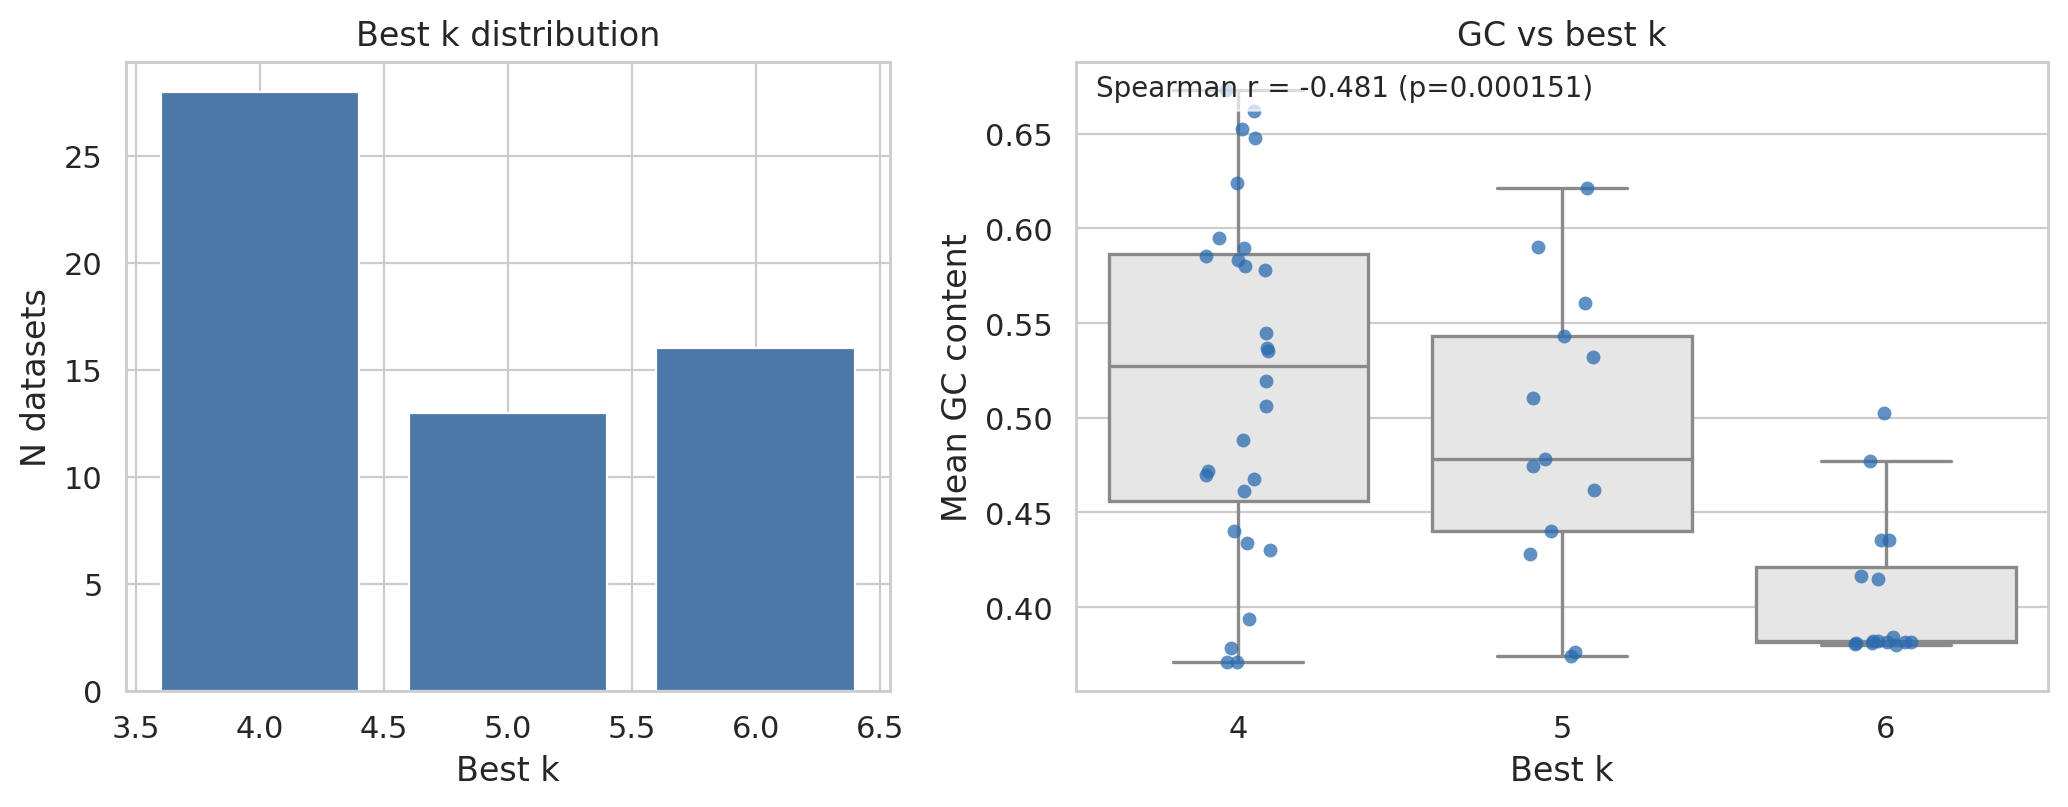

In [18]:
# ── Section 4: best k vs GC ─────────────────────────────────────────
bk = df_bestk.copy()
bk['biocat_label'] = bk['biocat'].map({
    'histone': 'Histone (Yeast)',
    'methylation': 'Methylation',
    'promoter': 'Promoter',
    'splice': 'Splice',
    'TFBS': 'TFBS',
    'enhancer/generic': 'Enhancer/Generic',
})

# Spearman GC vs best_k
rho_gc, p_gc = stats.spearmanr(bk['gc_content_mean'], bk['best_k'])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 4.2), gridspec_kw={'width_ratios': [1.1, 1.4]})

# counts best_k
counts = bk['best_k'].value_counts().sort_index()
ax0.bar(counts.index.astype(int), counts.values, color='#4C78A8')
ax0.set_xlabel('Best k')
ax0.set_ylabel('N datasets')
ax0.set_title('Best k distribution')

# GC vs best_k
sns.boxplot(data=bk, x='best_k', y='gc_content_mean', color='#E6E6E6',
            fliersize=0, linewidth=1.2, ax=ax1)
sns.stripplot(data=bk, x='best_k', y='gc_content_mean', color='#2B6CB0',
              size=5, alpha=0.75, ax=ax1)
ax1.set_xlabel('Best k')
ax1.set_ylabel('Mean GC content')
ax1.set_title('GC vs best k')
ax1.text(0.02, 0.98, f"Spearman r = {rho_gc:.3f} (p={p_gc:.3g})",
         transform=ax1.transAxes, va='top', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
save_figure(fig, '04_best_k_and_gc')
plt.show()

---
## 5. Embedding decomposition: R², projection, and residual
Compositional redundancy (R²) and comparison of projection/residual vs k-mer.

Saved figure: ../results/figures_pdf/05_decomposition_r2.pdf


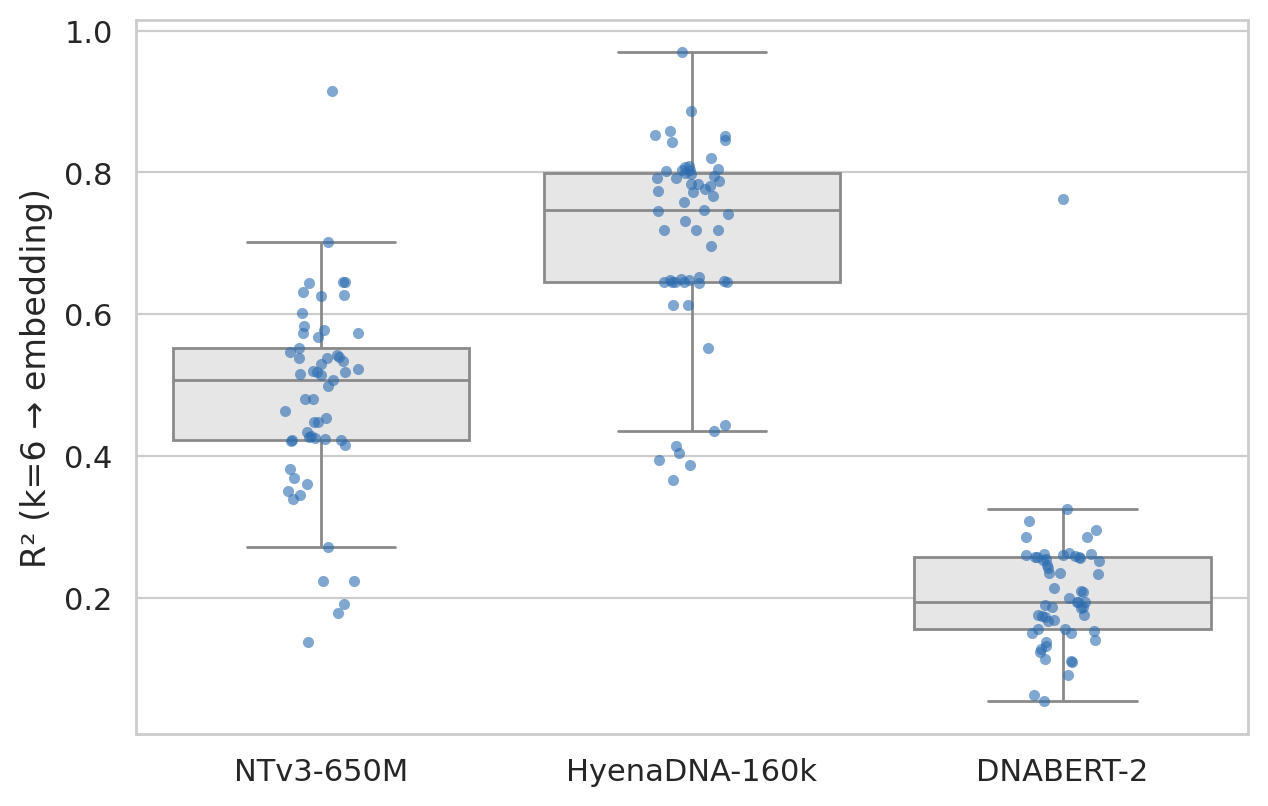

Saved figure: ../results/figures_pdf/05_decomposition_projection_residual.pdf


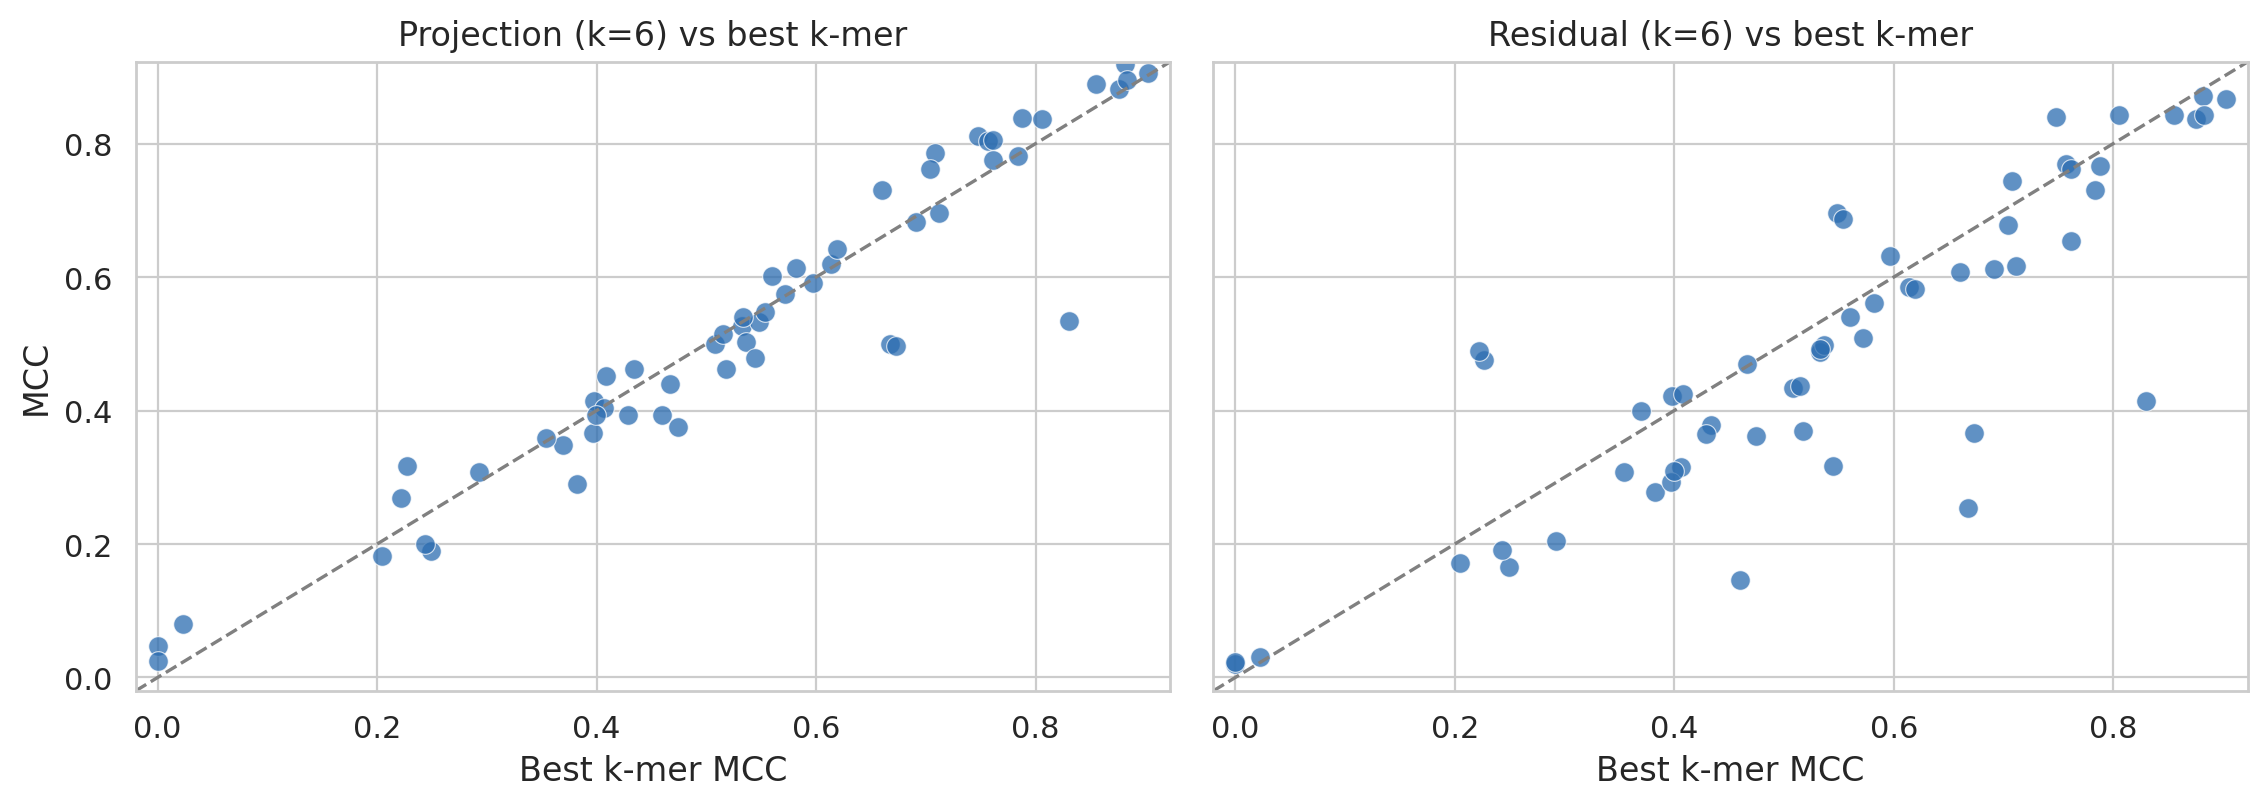

In [19]:
# ── Section 5: decomposition ────────────────────────────────────────
r2 = pd.DataFrame({
    'NTv3-650M': pd.to_numeric(df_decomp['ridge_k6_NTv3_650M_pre_R2'], errors='coerce'),
    'HyenaDNA-160k': pd.to_numeric(df_decomp['ridge_k6_hyenadna-medium-160k-seqlen-hf_R2'], errors='coerce'),
    'DNABERT-2': pd.to_numeric(df_decomp['ridge_k6_DNABERT-2-117M_R2'], errors='coerce'),
})
r2_long = r2.melt(var_name='Modello', value_name='R2')

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.boxplot(data=r2_long, x='Modello', y='R2', color='#E6E6E6', fliersize=0, ax=ax)
sns.stripplot(data=r2_long, x='Modello', y='R2', color='#2B6CB0', size=4, alpha=0.6, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('R² (k=6 → embedding)')
plt.tight_layout()
save_figure(fig, '05_decomposition_r2')
plt.show()

# projection vs k-mer, residual vs k-mer (NTv3)
proj = pd.to_numeric(df_decomp['proj_k6_NTv3_650M_pre_MCC'], errors='coerce')
resid = pd.to_numeric(df_decomp['resid_k6_NTv3_650M_pre_MCC'], errors='coerce')
best_k = best_kmer(df)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharex=True, sharey=True)
for ax, y, title in [
    (axes[0], proj, 'Projection (k=6) vs best k-mer'),
    (axes[1], resid, 'Residual (k=6) vs best k-mer')
]:
    ax.scatter(best_k, y, s=50, alpha=0.75, color='#2B6CB0', edgecolors='white', lw=0.4)
    lo = np.nanmin([best_k.min(), y.min()]) - 0.02
    hi = np.nanmax([best_k.max(), y.max()]) + 0.02
    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1.2)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(title)
    ax.set_xlabel('Best k-mer MCC')
axes[0].set_ylabel('MCC')
plt.tight_layout()
save_figure(fig, '05_decomposition_projection_residual')
plt.show()

---
## 6. Synergy between components
Distribution of synergy (full − max(proj, resid)) by category.

Saved figure: ../results/figures_pdf/06_synergy_by_category.pdf


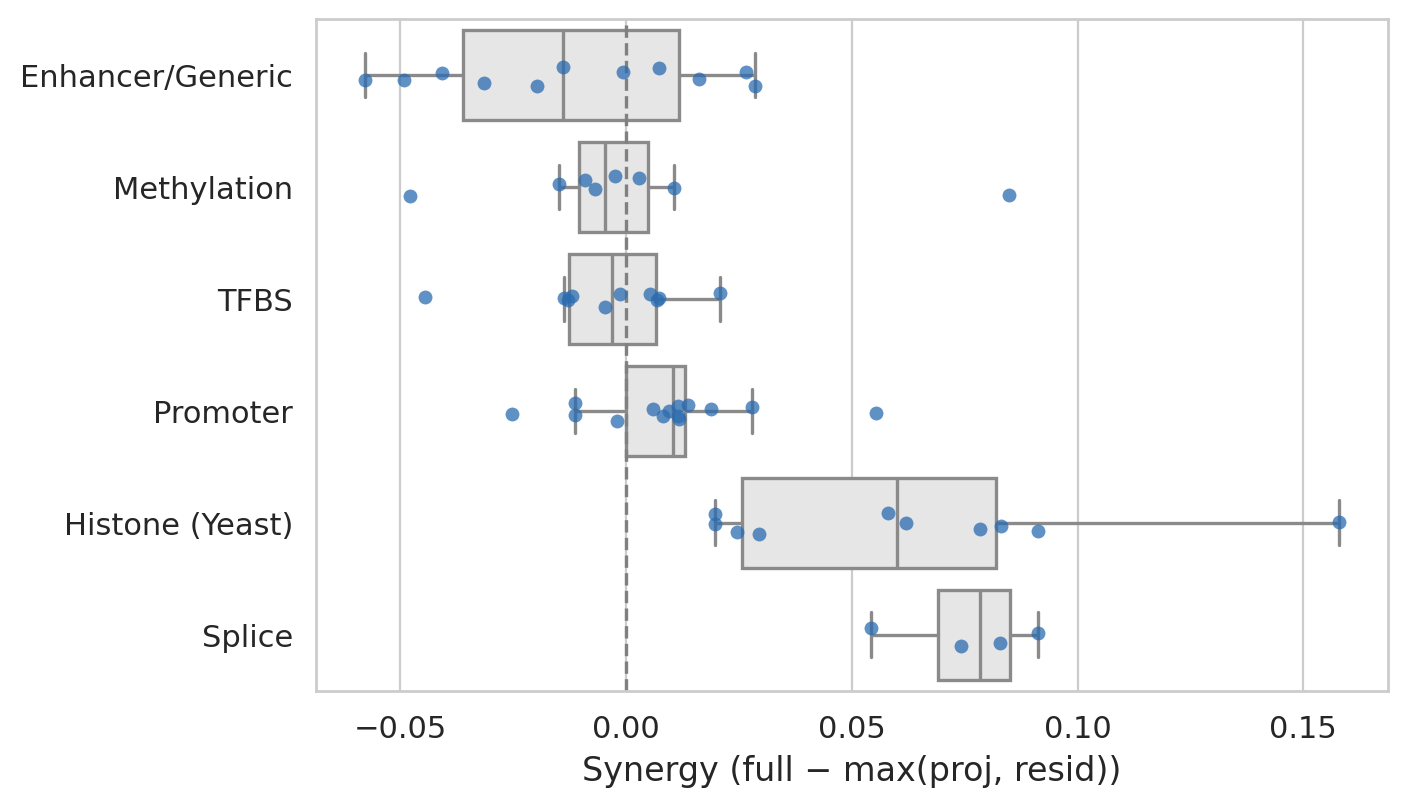

In [20]:
# ── Section 6: synergy ──────────────────────────────────────────────
sy = cat[['biocat_label', 'synergy']].dropna()
order = sy.groupby('biocat_label')['synergy'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.boxplot(data=sy, y='biocat_label', x='synergy', order=order,
            color='#E6E6E6', fliersize=0, linewidth=1.2, ax=ax)
sns.stripplot(data=sy, y='biocat_label', x='synergy', order=order,
              size=5, alpha=0.75, color='#2B6CB0', ax=ax)
ax.axvline(0, ls='--', c='gray', lw=1.2)
ax.set_xlabel('Synergy (full − max(proj, resid))')
ax.set_ylabel('')
plt.tight_layout()
save_figure(fig, '06_synergy_by_category')
plt.show()

---
## 7. Component comparison by model
MCC distributions for full embedding, projection, and residual.

Saved figure: ../results/figures_pdf/07_component_comparison_by_model.pdf


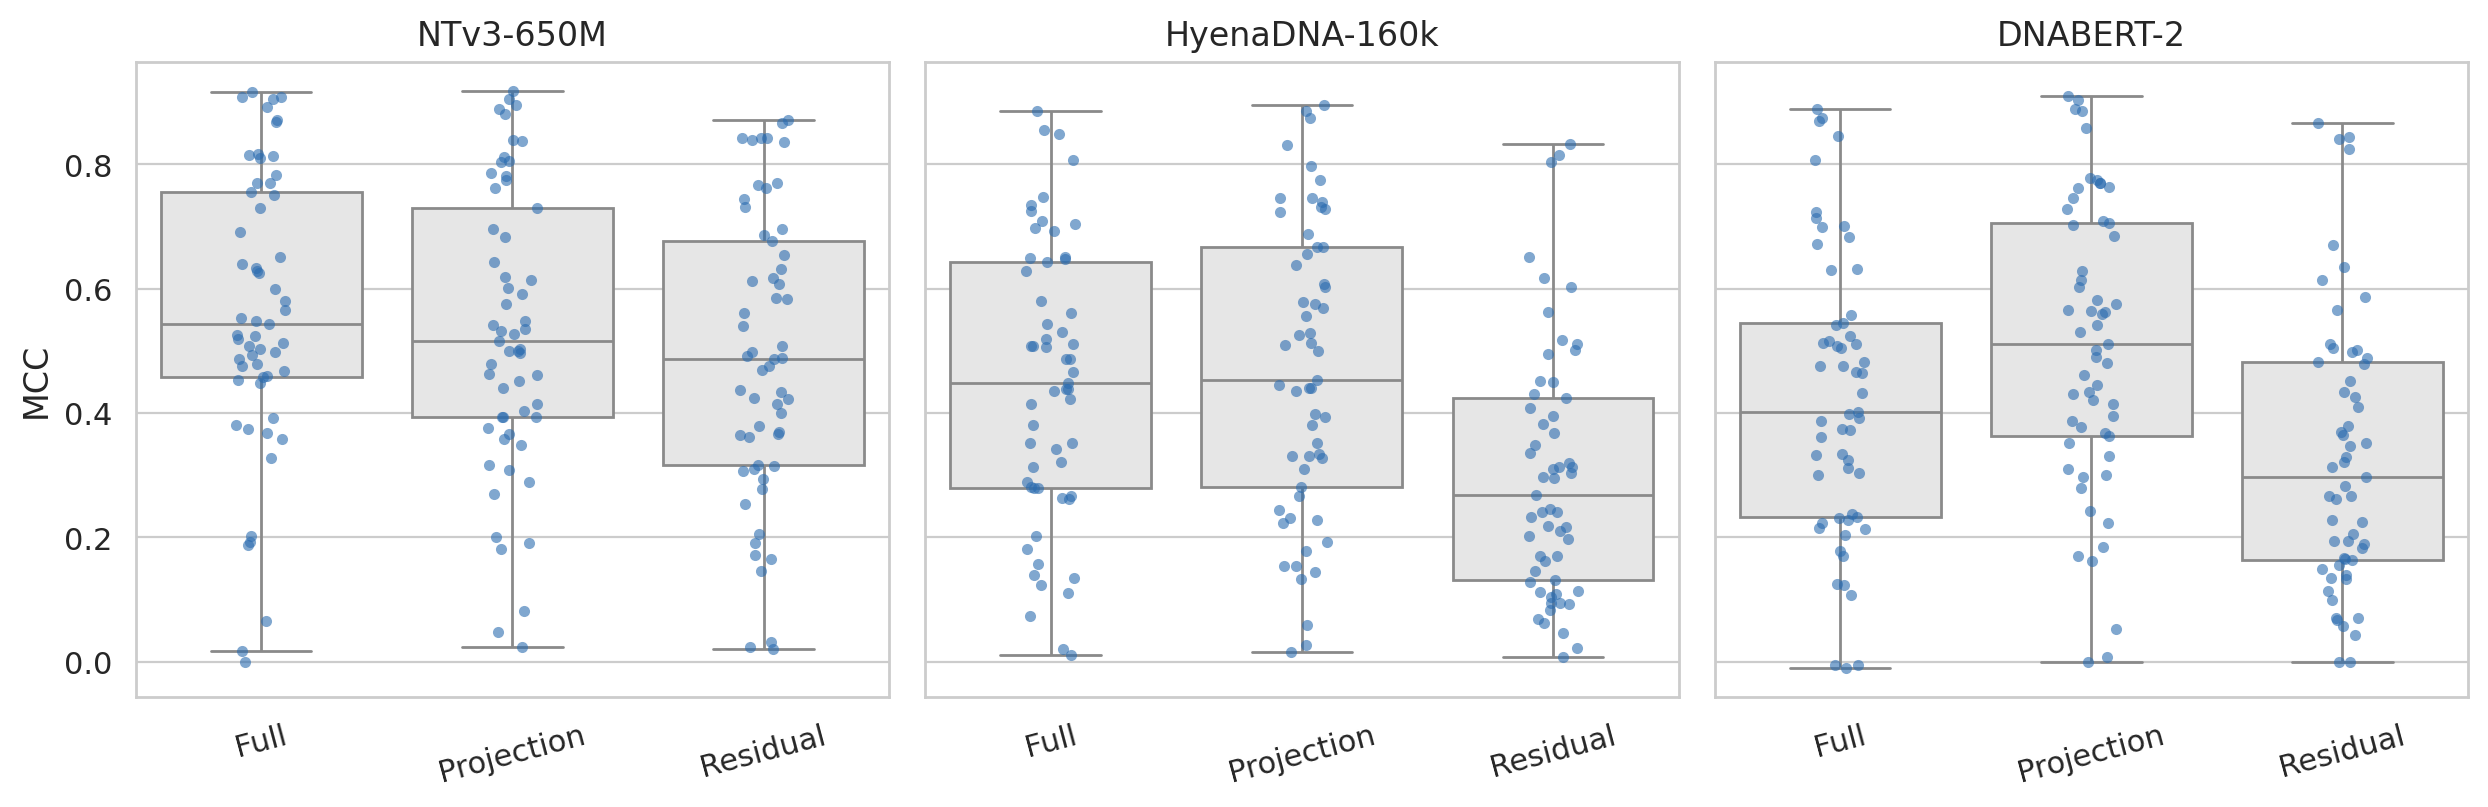

In [21]:
# ── Section 7: model comparison ────────────────────────────────────
def to_num(s):
    return pd.to_numeric(s, errors='coerce')

comp = []
# NTv3
comp.append(pd.DataFrame({'Modello':'NTv3-650M', 'Componente':'Full', 'MCC': to_num(df['fm_NTv3_650M_pre_MCC'])}))
comp.append(pd.DataFrame({'Modello':'NTv3-650M', 'Componente':'Projection', 'MCC': to_num(df_decomp['proj_k6_NTv3_650M_pre_MCC'])}))
comp.append(pd.DataFrame({'Modello':'NTv3-650M', 'Componente':'Residual', 'MCC': to_num(df_decomp['resid_k6_NTv3_650M_pre_MCC'])}))
# HyenaDNA
comp.append(pd.DataFrame({'Modello':'HyenaDNA-160k', 'Componente':'Full', 'MCC': to_num(df['fm_hyenadna-medium-160k-seqlen-hf_MCC'])}))
comp.append(pd.DataFrame({'Modello':'HyenaDNA-160k', 'Componente':'Projection', 'MCC': to_num(df_decomp['proj_k6_hyenadna-medium-160k-seqlen-hf_MCC'])}))
comp.append(pd.DataFrame({'Modello':'HyenaDNA-160k', 'Componente':'Residual', 'MCC': to_num(df_decomp['resid_k6_hyenadna-medium-160k-seqlen-hf_MCC'])}))
# DNABERT-2
comp.append(pd.DataFrame({'Modello':'DNABERT-2', 'Componente':'Full', 'MCC': to_num(df['fm_DNABERT-2-117M_MCC'])}))
comp.append(pd.DataFrame({'Modello':'DNABERT-2', 'Componente':'Projection', 'MCC': to_num(df_decomp['proj_k6_DNABERT-2-117M_MCC'])}))
comp.append(pd.DataFrame({'Modello':'DNABERT-2', 'Componente':'Residual', 'MCC': to_num(df_decomp['resid_k6_DNABERT-2-117M_MCC'])}))

comp = pd.concat(comp, ignore_index=True).dropna()

fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.2), sharey=True)
for ax, model in zip(axes, ['NTv3-650M', 'HyenaDNA-160k', 'DNABERT-2']):
    sub = comp[comp['Modello'] == model]
    sns.boxplot(data=sub, x='Componente', y='MCC', color='#E6E6E6', fliersize=0, ax=ax)
    sns.stripplot(data=sub, x='Componente', y='MCC', color='#2B6CB0', size=4, alpha=0.6, ax=ax)
    ax.set_title(model)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
axes[0].set_ylabel('MCC')
plt.tight_layout()
save_figure(fig, '07_component_comparison_by_model')
plt.show()

---
## 8. FM + k-mer concatenation
Distribution of Δ MCC for concatenation vs the best single method.

Saved figure: ../results/figures_pdf/08_concatenation_delta.pdf


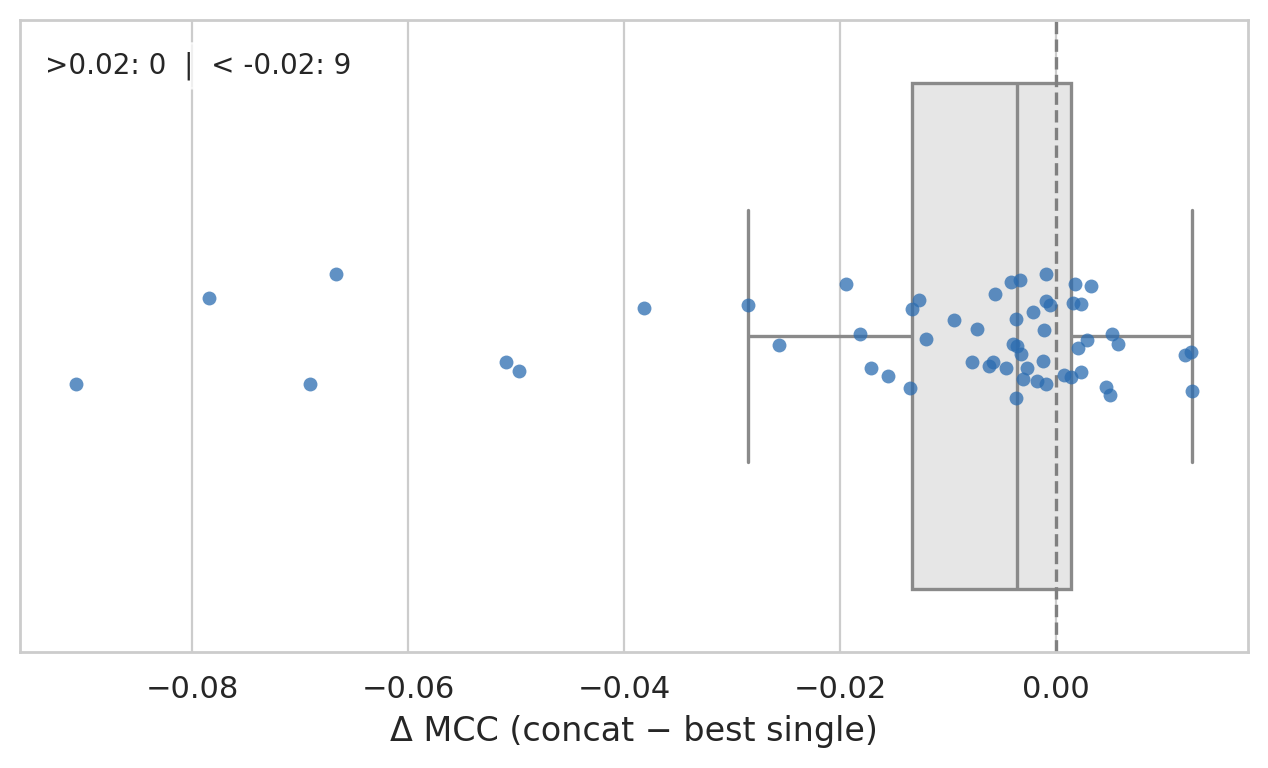

In [22]:
# ── Section 8: concatenation ───────────────────────────────────────
delta_c = cat['delta_concat'].dropna()
n_pos = (delta_c > 0.02).sum()
n_neg = (delta_c < -0.02).sum()

fig, ax = plt.subplots(figsize=(6.5, 4.0))
sns.boxplot(x=delta_c, color='#E6E6E6', fliersize=0, linewidth=1.2, ax=ax)
sns.stripplot(x=delta_c, color='#2B6CB0', size=5, alpha=0.75, ax=ax)
ax.axvline(0, ls='--', c='gray', lw=1.2)
ax.set_xlabel('Δ MCC (concat − best single)')
ax.set_yticks([])
ax.text(0.02, 0.95, f">0.02: {n_pos}  |  < -0.02: {n_neg}",
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
plt.tight_layout()
save_figure(fig, '08_concatenation_delta')
plt.show()

---
## 9. PCA effect
Δ MCC (PCA − native) for each representation.

Saved figure: ../results/figures_pdf/09_pca_effect.pdf


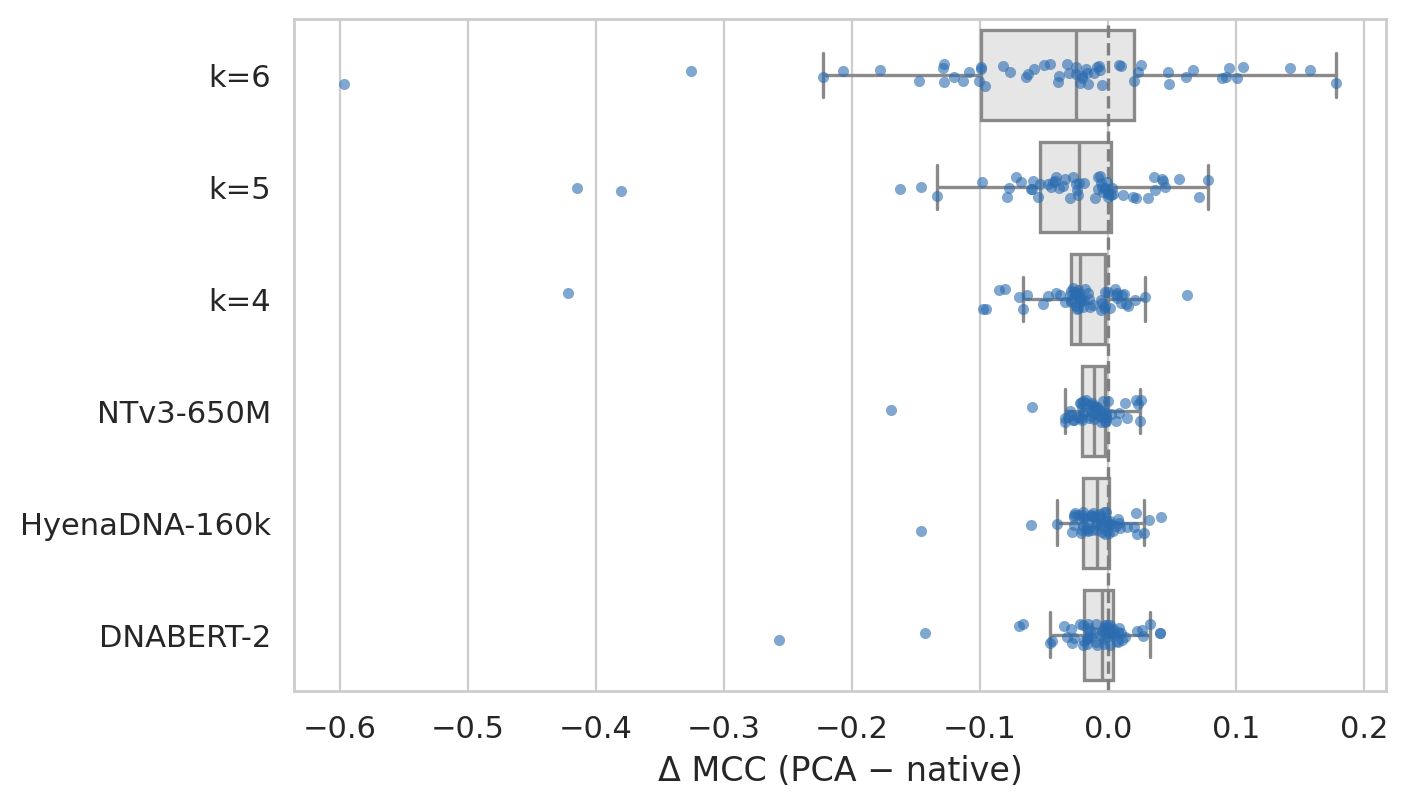

In [23]:
# ── Section 9: PCA effect ─────────────────────────────────────────-
pca_cols = {
    'NTv3-650M': ('pca_fm_NTv3_650M_pre_MCC', 'fm_NTv3_650M_pre_MCC'),
    'HyenaDNA-160k': ('pca_fm_hyenadna-medium-160k-seqlen-hf_MCC', 'fm_hyenadna-medium-160k-seqlen-hf_MCC'),
    'DNABERT-2': ('pca_fm_DNABERT-2-117M_MCC', 'fm_DNABERT-2-117M_MCC'),
    'k=4': ('pca_kmer_k4_MCC', 'kmer_k4_MCC'),
    'k=5': ('pca_kmer_k5_MCC', 'kmer_k5_MCC'),
    'k=6': ('pca_kmer_k6_MCC', 'kmer_k6_MCC'),
}

delta_list = []
for name, (pca_col, raw_col) in pca_cols.items():
    if pca_col in df_pca.columns and raw_col in df.columns:
        d = pd.to_numeric(df_pca[pca_col], errors='coerce') - pd.to_numeric(df[raw_col], errors='coerce')
        delta_list.append(pd.DataFrame({'Method': name, 'Δ MCC': d}))

delta_df = pd.concat(delta_list, ignore_index=True).dropna()
order = (delta_df.groupby('Method')['Δ MCC'].median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.boxplot(data=delta_df, y='Method', x='Δ MCC', order=order, color='#E6E6E6',
            fliersize=0, linewidth=1.2, ax=ax)
sns.stripplot(data=delta_df, y='Method', x='Δ MCC', order=order, color='#2B6CB0',
              size=4, alpha=0.6, ax=ax)
ax.axvline(0, ls='--', c='gray', lw=1.2)
ax.set_xlabel('Δ MCC (PCA − native)')
ax.set_ylabel('')
plt.tight_layout()
save_figure(fig, '09_pca_effect')
plt.show()

---
## 10. Compute cost (GFLOPS)
Per-sequence cost scaling with sequence length.

Saved figure: ../results/figures_pdf/10_efficiency_gflops_per_seq.pdf


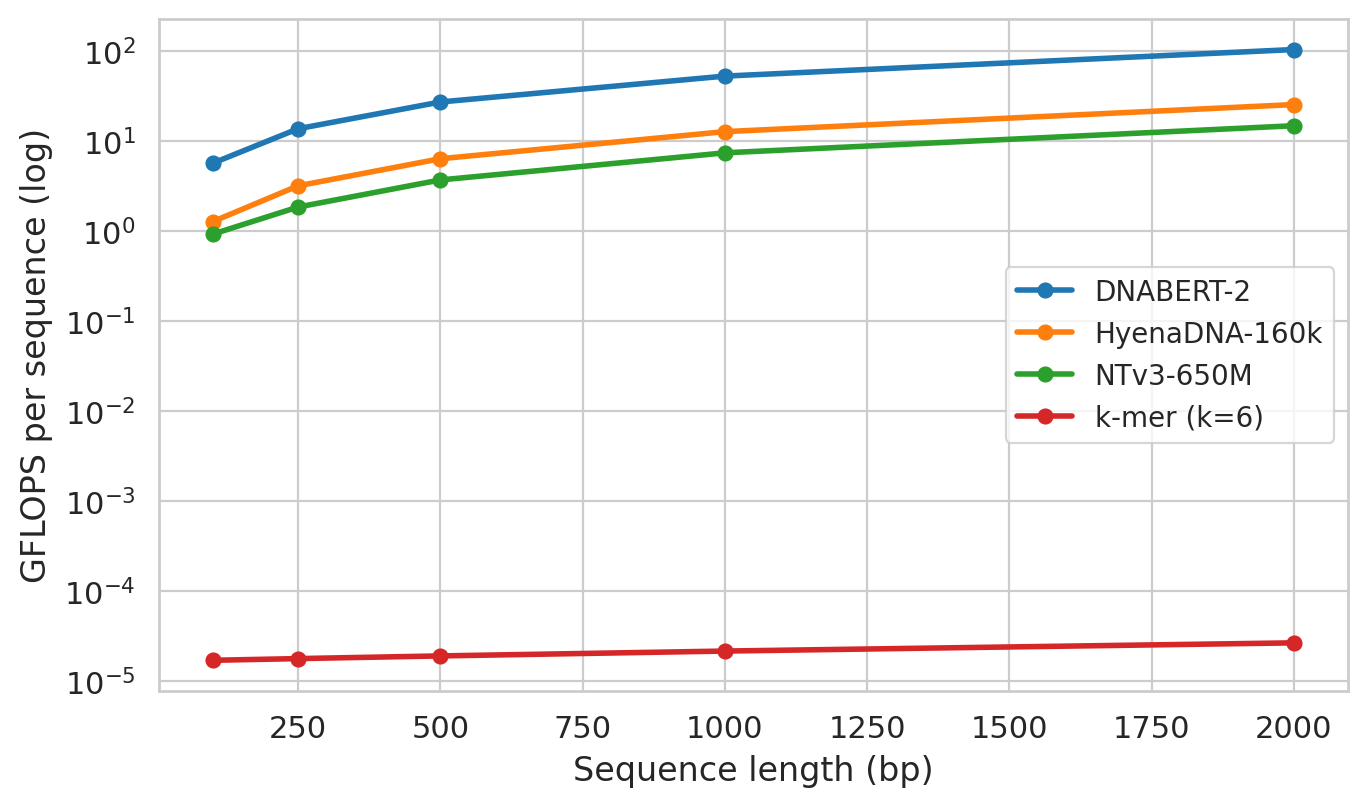

In [24]:
# ── Section 10: efficiency ─────────────────────────────────────────
eff = df_eff.copy()
eff['seq_len'] = pd.to_numeric(eff['seq_len'], errors='coerce')
eff['GFLOPS_per_seq'] = pd.to_numeric(eff['GFLOPS_per_seq'], errors='coerce')

method_map = {
    'fm_NTv3_650M_pre': 'NTv3-650M',
    'fm_hyenadna-medium-160k-seqlen-hf': 'HyenaDNA-160k',
    'fm_DNABERT-2-117M': 'DNABERT-2',
    'kmer_k6': 'k-mer (k=6)',
}
eff['Method'] = eff['method'].map(method_map)
eff = eff.dropna(subset=['Method'])

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for m, sub in eff.groupby('Method'):
    sub = sub.sort_values('seq_len')
    ax.plot(sub['seq_len'], sub['GFLOPS_per_seq'], marker='o', lw=2, label=m)

ax.set_yscale('log')
ax.set_xlabel('Sequence length (bp)')
ax.set_ylabel('GFLOPS per sequence (log)')
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, '10_efficiency_gflops_per_seq')
plt.show()

---
## 11. Cross-experiment correlations
Spearman correlation heatmap for key variables.

Saved figure: ../results/figures_pdf/11_cross_experiment_correlations.pdf


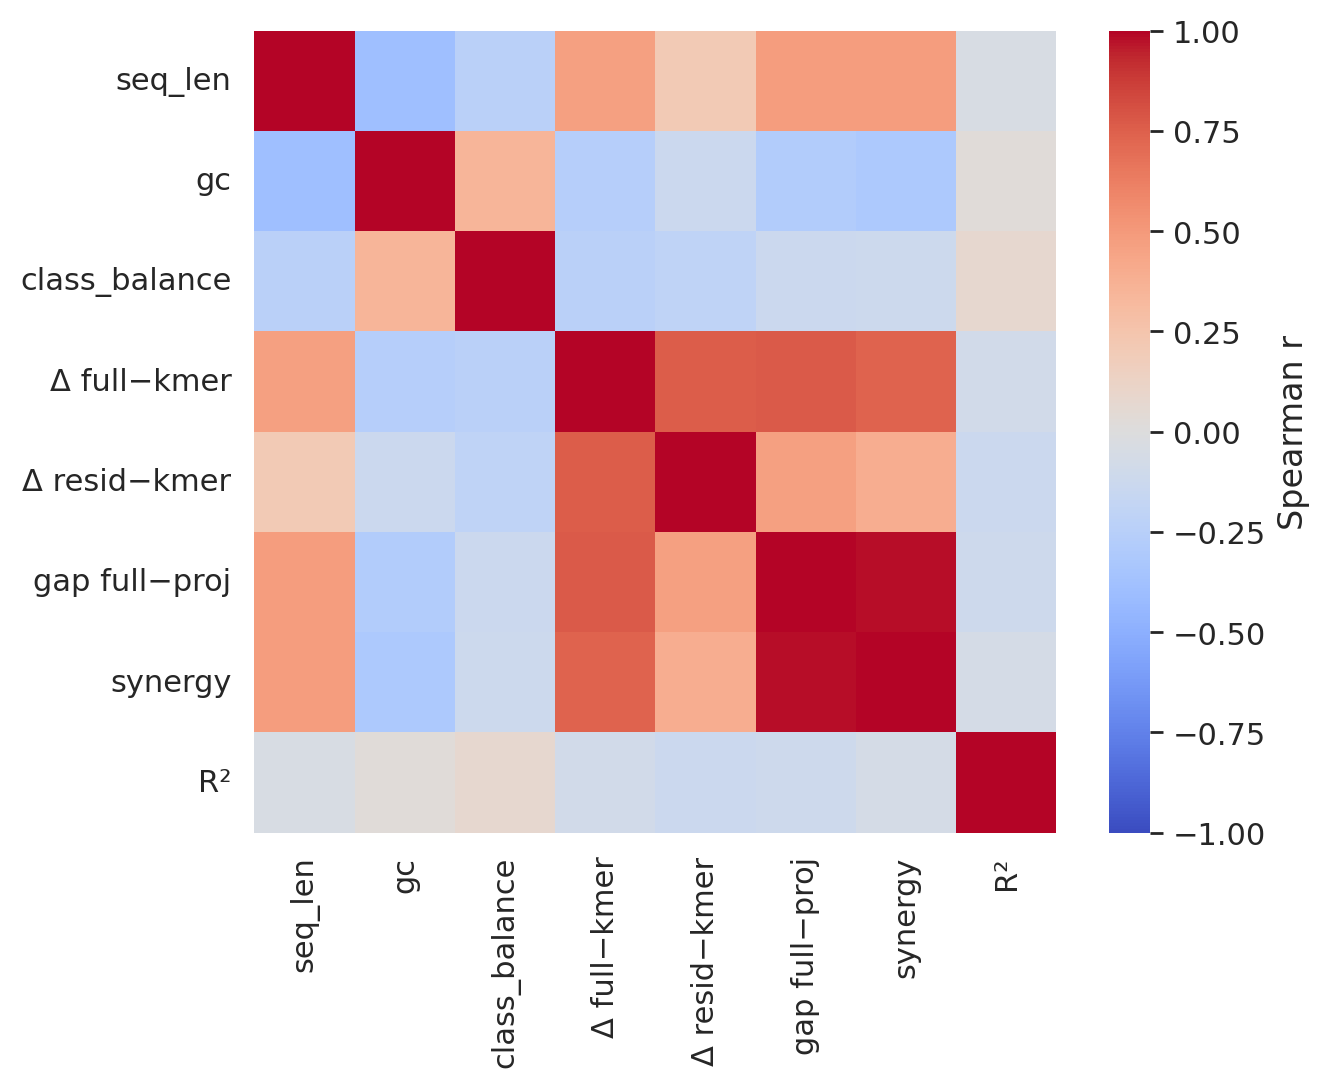

In [25]:
# ── Section 11: correlations ───────────────────────────────────────
corr = pd.DataFrame(index=df.index)
corr['seq_len'] = pd.to_numeric(df['seq_len_mean'], errors='coerce')
corr['gc'] = pd.to_numeric(df['gc_content_mean'], errors='coerce')
corr['class_balance'] = pd.to_numeric(df['class_balance'], errors='coerce')
corr['delta_full_kmer'] = pd.to_numeric(df['fm_NTv3_650M_pre_MCC'], errors='coerce') - best_kmer(df)
corr['delta_resid_kmer'] = pd.to_numeric(df_decomp['resid_k6_NTv3_650M_pre_MCC'], errors='coerce') - best_kmer(df)
corr['gap_full_proj'] = pd.to_numeric(df['fm_NTv3_650M_pre_MCC'], errors='coerce') - pd.to_numeric(df_decomp['proj_k6_NTv3_650M_pre_MCC'], errors='coerce')
corr['synergy'] = cat['synergy']
corr['R2'] = pd.to_numeric(df_decomp['ridge_k6_NTv3_650M_pre_R2'], errors='coerce')

corr = corr.dropna()

# readable labels for the heatmap
corr = corr.rename(columns={
    'seq_len': 'seq_len',
    'gc': 'gc',
    'class_balance': 'class_balance',
    'delta_full_kmer': 'Δ full−kmer',
    'delta_resid_kmer': 'Δ resid−kmer',
    'gap_full_proj': 'gap full−proj',
    'synergy': 'synergy',
    'R2': 'R²',
})

rho = corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(7.0, 5.6))
sns.heatmap(rho, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, cbar_kws={'label': 'Spearman r'}, ax=ax)
plt.tight_layout()
save_figure(fig, '11_cross_experiment_correlations')
plt.show()

---
## 12. Regression tasks (LRA)
Summary of performance on available regression datasets.

,k-mer (best k),NTv3-650M,HyenaDNA-1M,DNABERT-2
dataset,,,,
bulk_rna_expression,0.412,0.464,0.386,0.193
cage_prediction,0.573,0.518,0.567,0.400


Saved figure: ../results/figures_pdf/12_regression_r2_summary.pdf


/tmp/ipykernel_2774881/1661130347.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=reg_long, y='dataset', x='R2', hue='Method', orient='h', ci=None, ax=ax)


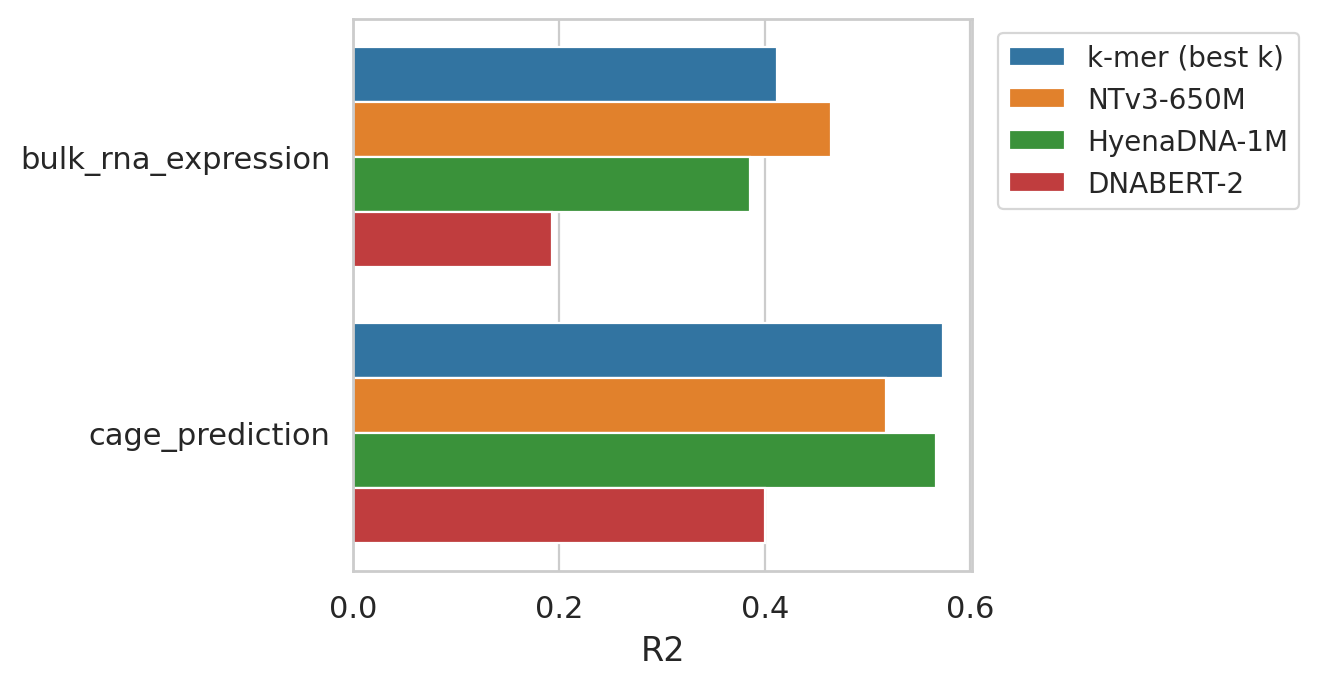

: 

In [ ]:
# ── Section 12: regression tasks ───────────────────────────────────
reg = df_reg.copy()
reg = reg.set_index('dataset')

# keep only datasets with regression metrics
r2_cols = [c for c in reg.columns if c.endswith('_R2')]
reg = reg[reg[r2_cols].notna().any(axis=1)]

# best k-mer (R2)
reg_k = reg[[c for c in reg.columns if c.startswith('kmer_k') and c.endswith('_R2')]]
reg['best_kmer_R2'] = reg_k.apply(pd.to_numeric, errors='coerce').max(axis=1)

# compact table (R2)
reg_table = reg[[
    'best_kmer_R2',
    'fm_NTv3_650M_pre_R2',
    'fm_hyenadna-large-1m-seqlen-hf_R2',
    'fm_DNABERT-2-117M_R2'
]].copy()
reg_table = reg_table.rename(columns={
    'best_kmer_R2': 'k-mer (best k)',
    'fm_NTv3_650M_pre_R2': 'NTv3-650M',
    'fm_hyenadna-large-1m-seqlen-hf_R2': 'HyenaDNA-1M',
    'fm_DNABERT-2-117M_R2': 'DNABERT-2',
})
reg_table = reg_table.round(3)

display(reg_table)

# plot: R2 by dataset and method
reg_long = reg_table.reset_index().melt(id_vars='dataset', var_name='Method', value_name='R2')

fig, ax = plt.subplots(figsize=(6.8, 3.6))
sns.barplot(data=reg_long, y='dataset', x='R2', hue='Method', orient='h', ci=None, ax=ax)
ax.set_xlabel('R2')
ax.set_ylabel('')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
save_figure(fig, '12_regression_r2_summary')
plt.show()